<a href="https://colab.research.google.com/github/JohnJomi/Comparison-Linear-Regression-Gaussian-Process-/blob/main/MSE_Lab_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

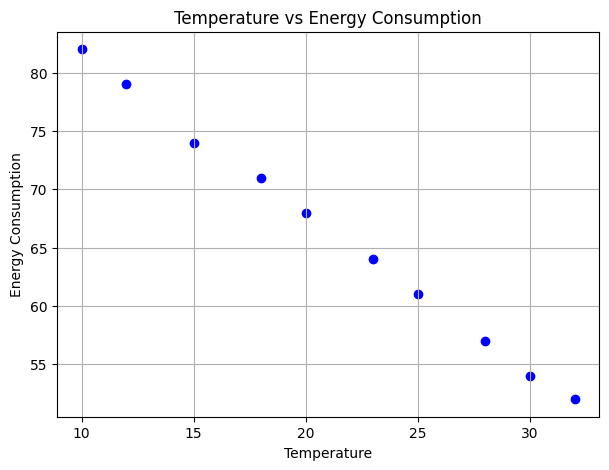

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C

# Dataset
temp = np.array([10, 12, 15, 18, 20, 23, 25, 28, 30, 32]).reshape(-1, 1)
energy = np.array([82, 79, 74, 71, 68, 64, 61, 57, 54, 52])

plt.figure(figsize=(7,5))
plt.scatter(temp, energy, color='blue')
plt.xlabel("Temperature")
plt.ylabel("Energy Consumption")
plt.title("Temperature vs Energy Consumption")
plt.grid(True)
plt.show()

Regression equation: energy = -1.3658 * temp + 95.2907
Predicted energy at 17°C: 72.07
Predicted energy at 22°C: 65.24
Predicted energy at 29°C: 55.68

Linear Regression -> MAE: 0.264, RMSE: 0.345


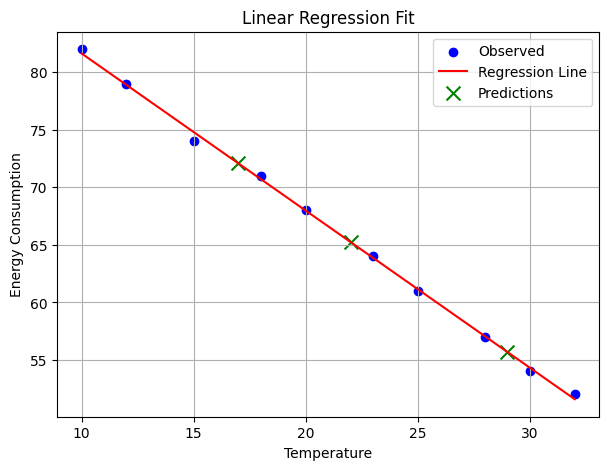

In [ ]:
# Fit linear regression
lin_reg = LinearRegression()
lin_reg.fit(temp, energy)

# Predictions for 17, 22, 29
new_temps = np.array([17, 22, 29]).reshape(-1, 1)
lin_preds = lin_reg.predict(new_temps)

print("Regression equation: energy = {:.4f} * temp + {:.4f}".format(
    lin_reg.coef_[0], lin_reg.intercept_))

for t, p in zip([17, 22, 29], lin_preds):
    print(f"Predicted energy at {t}°C: {p:.2f}")

# Metrics on training data
energy_pred_train = lin_reg.predict(temp)
mae_lin = mean_absolute_error(energy, energy_pred_train)
rmse_lin = np.sqrt(mean_squared_error(energy, energy_pred_train))
print(f"\nLinear Regression -> MAE: {mae_lin:.3f}, RMSE: {rmse_lin:.3f}")

# Plot regression line with observed data
plt.figure(figsize=(7,5))
plt.scatter(temp, energy, color='blue', label='Observed')
temp_line = np.linspace(temp.min(), temp.max(), 100).reshape(-1,1)
plt.plot(temp_line, lin_reg.predict(temp_line), color='red', label='Regression Line')
plt.scatter(new_temps, lin_preds, color='green', marker='x', s=100, label='Predictions')
plt.xlabel("Temperature")
plt.ylabel("Energy Consumption")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



--- GP with RBF Kernel ---
Learned kernel: 7**2 * RBF(length_scale=83.5) + WhiteKernel(noise_level=0.00161)
Predicted energy at 17°C: 72.03 ± 0.84 (95% CI)
Predicted energy at 22°C: 65.13 ± 0.85 (95% CI)
Predicted energy at 29°C: 55.69 ± 0.85 (95% CI)
MAE: 0.249, RMSE: 0.333

--- GP with Matern Kernel ---
Learned kernel: 4.62**2 * Matern(length_scale=100, nu=1.5) + WhiteKernel(noise_level=0.000835)
Predicted energy at 17°C: 71.90 ± 0.73 (95% CI)
Predicted energy at 22°C: 65.35 ± 0.72 (95% CI)
Predicted energy at 29°C: 55.50 ± 0.70 (95% CI)
MAE: 0.141, RMSE: 0.170


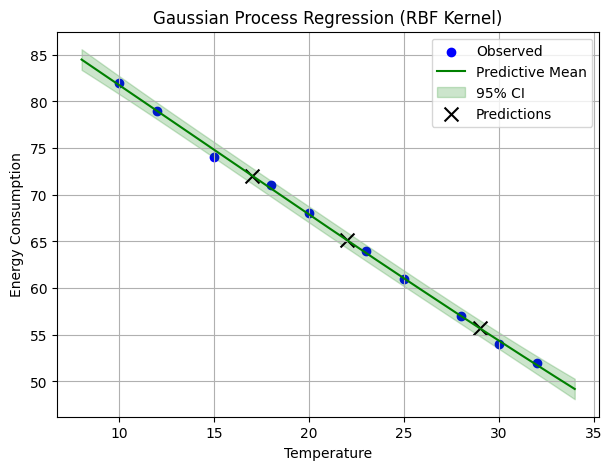

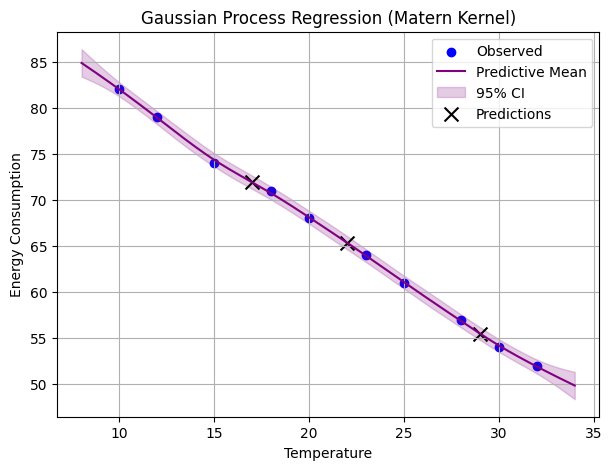

Model Comparison
Model               MAE       RMSE      
Linear Regression   0.264     0.345     
GP (RBF)            0.249     0.333     
GP (Matern)         0.141     0.170     


In [ ]:
# Kernel 1: RBF
kernel1 = C(1.0, (1e-3, 1e3)) * RBF(length_scale=5, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1)
gp1 = GaussianProcessRegressor(kernel=kernel1, n_restarts_optimizer=10, normalize_y=True)
gp1.fit(temp, energy)

# Kernel 2: Matern
kernel2 = C(1.0, (1e-3, 1e3)) * Matern(length_scale=5, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=1)
gp2 = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=10, normalize_y=True)
gp2.fit(temp, energy)

def evaluate_gp(gp, name):
    mean_pred, std_pred = gp.predict(new_temps, return_std=True)
    print(f"\n--- {name} ---")
    print("Learned kernel:", gp.kernel_)
    for t, m, s in zip([17, 22, 29], mean_pred, std_pred):
        print(f"Predicted energy at {t}°C: {m:.2f} ± {1.96*s:.2f} (95% CI)")

    train_pred = gp.predict(temp)
    mae = mean_absolute_error(energy, train_pred)
    rmse = np.sqrt(mean_squared_error(energy, train_pred))
    print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}")
    return mean_pred, std_pred, mae, rmse

mean1, std1, mae1, rmse1 = evaluate_gp(gp1, "GP with RBF Kernel")
mean2, std2, mae2, rmse2 = evaluate_gp(gp2, "GP with Matern Kernel")

# Plotting function
def plot_gp(gp, name, color):
    temp_line = np.linspace(temp.min()-2, temp.max()+2, 200).reshape(-1,1)
    mean_line, std_line = gp.predict(temp_line, return_std=True)

    plt.figure(figsize=(7,5))
    plt.scatter(temp, energy, color='blue', label='Observed')
    plt.plot(temp_line, mean_line, color=color, label='Predictive Mean')
    plt.fill_between(temp_line.ravel(),
                      mean_line - 1.96*std_line,
                      mean_line + 1.96*std_line,
                      alpha=0.2, color=color, label='95% CI')
    plt.scatter(new_temps, gp.predict(new_temps), color='black', marker='x', s=100, label='Predictions')
    plt.xlabel("Temperature")
    plt.ylabel("Energy Consumption")
    plt.title(f"Gaussian Process Regression ({name})")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_gp(gp1, "RBF Kernel", "green")
plot_gp(gp2, "Matern Kernel", "purple")


print("Model Comparison")
print(f"{'Model':<20}{'MAE':<10}{'RMSE':<10}")
print(f"{'Linear Regression':<20}{mae_lin:<10.3f}{rmse_lin:<10.3f}")
print(f"{'GP (RBF)':<20}{mae1:<10.3f}{rmse1:<10.3f}")
print(f"{'GP (Matern)':<20}{mae2:<10.3f}{rmse2:<10.3f}")